In [1]:
import utils as ut
import pandas as pd

# Validation

#### W tuning results and performance relative to benchmarks

In [6]:
static_benchmarks = pd.read_parquet(f'{ut.results_dir}/benchmarks/nll_only/')
ll_tuning_run = pd.read_parquet(f'{ut.results_dir}/LL_runner/nll_only/')

# Selecting relevant columns
ll_tuning_run['model_name'] = ll_tuning_run['hurdle_model'].map({True: 'LL_hurdle', False: 'LL_NB'})
ll_tuning_run = ll_tuning_run[['w_inf', 'model_name', 'test_valid', 'non_degen_ll', 'run_timestamp']]
static_benchmarks['w_inf'] = 0

results = pd.concat([ll_tuning_run, static_benchmarks])
results.sort_values(by='non_degen_ll', ascending=False).head()

,w_inf,model_name,test_valid,non_degen_ll,run_timestamp,experiment_name,seed,hurdle_model
4,0.25,LL_hurdle,valid,-1.406662,20260810_155952_798324,NaN,NaN,NaN
14,0.26,LL_hurdle,valid,-1.406713,20260810_170528_560531,NaN,NaN,NaN
13,0.24,LL_hurdle,valid,-1.406725,20260810_170420_378925,NaN,NaN,NaN
15,0.27,LL_hurdle,valid,-1.406875,20260810_170636_462556,NaN,NaN,NaN
12,0.23,LL_hurdle,valid,-1.406901,20260810_170310_618712,NaN,NaN,NaN


In [7]:
results = results.reset_index(drop=True)
results.loc[results.groupby('model_name')['non_degen_ll'].idxmax()].sort_values(by='non_degen_ll', ascending=False)

,w_inf,model_name,test_valid,non_degen_ll,run_timestamp,experiment_name,seed,hurdle_model
4,0.25,LL_hurdle,valid,-1.406662,20260810_155952_798324,NaN,NaN,NaN
19,0.00,static_user_hour_hurdle,valid,-1.491693,20260810_165734_822592,benchmark,6654.0,True
18,0.00,static_user_hurdle,valid,-1.491866,20260810_165734_822592,benchmark,6654.0,True


#### Cluster Smoothing validaiton performance

In [2]:
cluster_smoothing = pd.read_parquet(f'{ut.results_dir}/cluster_smoothing/nll_only/')

In [3]:
cluster_smoothing.sort_values(by='non_degen_ll', ascending=False).head(10)

,smoothed_model_name,experiment_name,seed,w_inf,cluster_param,smooth_a_mu,smooth_a_sigma2,smooth_a_p,smooth_t_mu,smooth_t_sigma2,...,constant_alpha,smoothing_target,hurdle_model,test_valid,non_degen_ll,clustering_matrix_name,clustering_transformation,distance_metric,cluster_inertia,run_timestamp
328,k_clusters,cluster_smoothing,6654,0.31,16,0.65,0.60,0.35,0.0,0.0,...,True,1,True,valid,-1.398561,all,none,standardised_l2,155291.875000,20260811_034150_848030
321,k_clusters,cluster_smoothing,6654,0.33,16,0.50,0.55,0.25,0.0,0.0,...,True,1,True,valid,-1.398697,all,none,standardised_l2,155291.875000,20260811_033212_240184
373,k_clusters,cluster_smoothing,6654,0.31,28,0.50,0.55,0.25,0.0,0.0,...,True,1,True,valid,-1.398750,all,none,standardised_l2,107447.562500,20260811_044353_006559
291,k_clusters,cluster_smoothing,6654,0.31,20,0.55,0.55,0.20,0.0,0.0,...,True,1,True,valid,-1.398808,u_p,none,standardised_l2,106852.945312,20260811_025048_550944
333,k_clusters,cluster_smoothing,6654,0.32,22,0.40,0.50,0.20,0.0,0.0,...,True,1,True,valid,-1.398858,all,none,standardised_l2,121895.039062,20260811_034844_211758
344,k_clusters,cluster_smoothing,6654,0.33,26,0.55,0.60,0.20,0.0,0.0,...,True,1,True,valid,-1.398929,all,none,standardised_l2,112232.984375,20260811_040353_923753
336,k_clusters,cluster_smoothing,6654,0.31,32,0.60,0.55,0.30,0.0,0.0,...,True,1,True,valid,-1.398990,u_p,none,standardised_l2,79655.664062,20260811_035253_049372
271,k_clusters,cluster_smoothing,6654,0.32,18,0.40,0.45,0.25,0.0,0.0,...,True,1,True,valid,-1.398997,all,none,standardised_l2,138624.796875,20260811_022313_145784
383,k_clusters,cluster_smoothing,6654,0.31,32,0.45,0.45,0.25,0.0,0.0,...,True,1,True,valid,-1.399133,u_p,none,standardised_l2,79655.664062,20260811_045739_261145
10,k_clusters,cluster_smoothing,6654,0.34,24,0.60,0.55,0.25,0.0,0.0,...,True,1,True,valid,-1.399162,all,none,standardised_l2,118243.179688,20260810_172808_880450


In [3]:
cluster_smoothing.sort_values(by='non_degen_ll', ascending=False).iloc[0]

smoothed_model_name                      k_clusters
experiment_name                   cluster_smoothing
seed                                           6654
w_inf                                          0.31
cluster_param                                    16
smooth_a_mu                                    0.65
smooth_a_sigma2                                 0.6
smooth_a_p                                     0.35
smooth_t_mu                                     0.0
smooth_t_sigma2                                 0.0
smooth_t_p                                      0.0
constant_alpha                                 True
smoothing_target                                  1
hurdle_model                                   True
test_valid                                    valid
non_degen_ll                              -1.398561
clustering_matrix_name                          all
clustering_transformation                      none
distance_metric                     standardised_l2
cluster_iner

#### Global Smoothing Validation performance

In [ ]:
global_smoothing = pd.read_parquet(f'{ut.results_dir}/global_smoothing/nll_only/')

In [12]:
global_smoothing.sort_values(by='non_degen_ll', ascending=False).head()

,smoothed_model_name,experiment_name,seed,w_inf,cluster_param,smooth_a_mu,smooth_a_sigma2,smooth_a_p,smooth_t_mu,smooth_t_sigma2,...,constant_alpha,smoothing_target,hurdle_model,test_valid,non_degen_ll,clustering_matrix_name,clustering_transformation,distance_metric,cluster_inertia,run_timestamp
297,k_clusters,global_smoothing,6654,0.28,1,0.45,0.45,0.1,0.0,0.0,...,True,1,True,valid,-1.404316,u,none,l2,0.0,20260811_085154_514265
363,k_clusters,global_smoothing,6654,0.28,1,0.50,0.45,0.1,0.0,0.0,...,True,1,True,valid,-1.404364,u,none,l2,0.0,20260811_100554_975036
229,k_clusters,global_smoothing,6654,0.30,1,0.50,0.50,0.1,0.0,0.0,...,True,1,True,valid,-1.404461,u,none,l2,0.0,20260811_073523_810971
334,k_clusters,global_smoothing,6654,0.28,1,0.50,0.60,0.1,0.0,0.0,...,True,1,True,valid,-1.404567,u,none,l2,0.0,20260811_093456_073988
352,k_clusters,global_smoothing,6654,0.28,1,0.60,0.65,0.1,0.0,0.0,...,True,1,True,valid,-1.404767,u,none,l2,0.0,20260811_095546_369211


In [13]:
global_smoothing.sort_values(by='non_degen_ll', ascending=False).iloc[0]

smoothed_model_name                      k_clusters
experiment_name                    global_smoothing
seed                                           6654
w_inf                                          0.28
cluster_param                                     1
smooth_a_mu                                    0.45
smooth_a_sigma2                                0.45
smooth_a_p                                      0.1
smooth_t_mu                                     0.0
smooth_t_sigma2                                 0.0
smooth_t_p                                      0.0
constant_alpha                                 True
smoothing_target                                  1
hurdle_model                                   True
test_valid                                    valid
non_degen_ll                              -1.404316
clustering_matrix_name                            u
clustering_transformation                      none
distance_metric                                  l2
cluster_iner

# Test

In [1]:
import l_result_preperation as l
import matplotlib.pyplot as plt
import numpy as np 
import utils as ut
import os 
import m_plots as m

outputs_dir = f'{ut.project_root}/outputs'
os.makedirs(outputs_dir, exist_ok=True)

In [2]:
# Loading in test results and concat together
runtime_configs = ut.load_json5('runtime_configs')
ll_full_results, ll_user_results, benchmark_results = l.load_test_results(results_dir=ut.results_dir, n_test_seeds=runtime_configs['n_test_seeds'])

##### Processing Data

In [3]:
overall_performance = l.get_all_model_performance_table(ll_full_results=ll_full_results, benchmark_results=benchmark_results)
l.store_results(overall_performance, ut.results_dir, 'overall_performance')

In [4]:
model_comparisons = l.prepare_model_comparisons(ll_user_results=ll_user_results, overall_performance=overall_performance)
l.store_results(model_comparisons, ut.results_dir, 'model_comparisons')

In [5]:
activity_decile = l.get_activity_decile_improvement(ll_full_results=ll_full_results)
l.store_results(activity_decile, ut.results_dir, 'activity_decile')

In [6]:
distance_decile = l.get_distance_decile_improvement(ll_user_results=ll_user_results)
l.store_results(distance_decile, ut.results_dir, 'distance_decile')

In [7]:
calibration = l.get_calibration_summary(ll_full_results=ll_full_results)
l.store_results(calibration, ut.results_dir, 'calibration')

In [8]:
user_type_summary = l.get_user_type_summary(ll_full_results=ll_full_results, benchmark_results=benchmark_results)
l.store_results(user_type_summary, ut.results_dir, 'user_type_summary')

In [9]:
detection = l.get_attack_detection_summary(results_dir=ut.results_dir, n_test_seeds=runtime_configs['n_test_seeds'])
l.store_results(detection, ut.results_dir, 'attack_detection')

##### Activity decile plot

In [10]:
# activity_decile = l.load_results( ut.results_dir, 'activity_decile')
# fig, ax = m.declile_log_likelihood_plot(decile_results=activity_decile, x_label='Activity decile', relative=False)
# # fig.savefig(f'{outputs_dir}/activity_decile.pdf', bbox_inches='tight', pad_inches=0.02)
# plt.show()

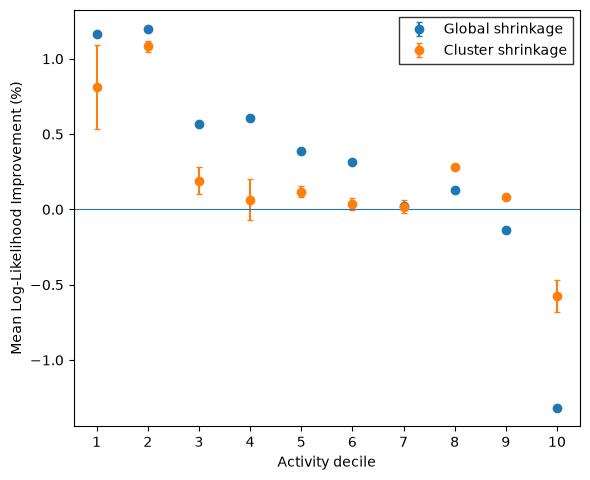

In [11]:
activity_decile = l.load_results(ut.results_dir, 'activity_decile')
fig, ax = m.declile_log_likelihood_plot(decile_results=activity_decile, x_label='Activity decile', relative=True)
fig.savefig(f'{outputs_dir}/activity_decile_relative.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

##### Distance decile plot

In [12]:
# distance_decile = l.load_results( ut.results_dir, 'distance_decile')
# fig, ax = m.declile_log_likelihood_plot(decile_results=distance_decile, x_label='Distance decile', relative=False)
# # fig.savefig(f'{outputs_dir}/distance_decile.pdf', bbox_inches='tight', pad_inches=0.02)
# plt.show()

In [13]:
# distance_decile = l.load_results(ut.results_dir, 'distance_decile')
# fig, ax = m.declile_log_likelihood_plot(decile_results=distance_decile, x_label='Distance decile', relative=True)
# fig.savefig(f'{outputs_dir}/distance_decile_relative.pdf', bbox_inches='tight', pad_inches=0.02)
# plt.show()

##### Calibration plot

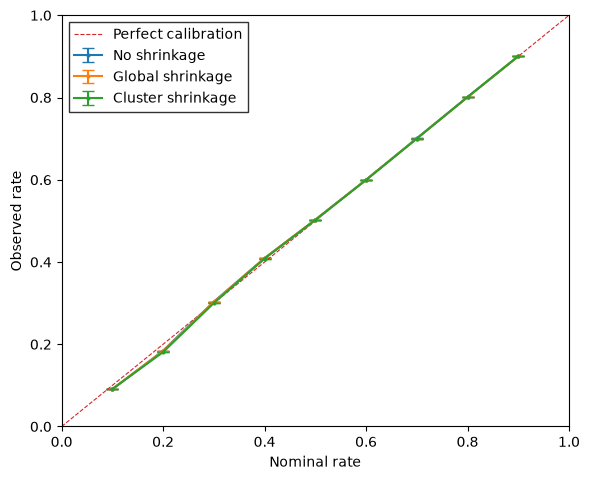

In [14]:
calibration = l.load_results( ut.results_dir, 'calibration')
fig, ax = m.plot_calibration(calibration_df=calibration, extreme=False)
# fig.savefig(f'{outputs_dir}/decile_calibration.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

##### Extreme Calibration Table + plot

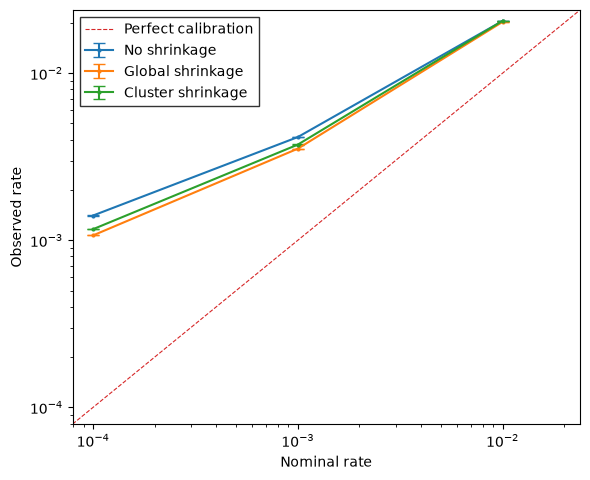

In [15]:
calibration = l.load_results( ut.results_dir, 'calibration')
fig, ax = m.plot_calibration(calibration_df=calibration, extreme=True)
# fig.savefig(f'{outputs_dir}/extreme_calibration.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

In [16]:
# calibration = l.load_results(ut.results_dir, 'calibration',)
# extreme_calibration_output = l.get_extreme_calibration_output(calibration)
# extreme_calibration_output

# extreme_calibration_output.to_csv(f'{outputs_dir}/extreme_calibration.csv', index=False)

##### User Type Breakdown Table

In [32]:
user_type_summary = l.load_results(ut.results_dir, 'user_type_summary')
user_type_output = l.get_user_type_output(user_type_summary)


user_type_output['No shrinkage'] = user_type_output['no_smoothing'].apply(lambda x: f'{x:.5f}')
user_type_output['Global shrinkage'] = user_type_output['global_smoothing'].apply(lambda x: f'{x:.5f}')
user_type_output['Cluster shrinkage'] = np.where(
    user_type_output['cluster_smoothing_seed_sd'].notna(),
    user_type_output['cluster_smoothing'].apply(lambda x: f'{x:.5f}') + ' $\pm$ ' + user_type_output['cluster_smoothing_seed_sd'].apply(lambda x: f'{x:.5f}'),
    user_type_output['cluster_smoothing'].apply(lambda x: f'{x:.5f}'))

user_type_output = user_type_output[['user_type', 'No shrinkage', 'Global shrinkage', 'Cluster shrinkage']].rename(columns={'user_type': 'User type'})
# user_type_output.to_csv(f'{outputs_dir}/user_type_performance.csv', index=False)

##### Overall Comparison Table

In [18]:
overall_performance = l.load_results(ut.results_dir, 'overall_performance')
user_type_summary = l.load_results(ut.results_dir, 'user_type_summary')
overall_performance_output = l.get_overall_performance_output(overall_performance, user_type_summary)
overall_performance_output
#overall_performance_output.to_csv(f'{outputs_dir}/overall_performance.csv', index=False)

,Model,Overall,$\Delta$ LL,Human,Machine
0,Cluster shrinkage,-1.37401 $\pm$ 0.00027,+0.00042,-1.01573 $\pm$ 0.00071,-1.61426 $\pm$ 0.00029
1,No shrinkage,-1.37442,-,-1.00846,-1.61983
2,Global shrinkage,-1.37502,-0.00060,-1.01257,-1.61807
3,Hourly user benchmark,-1.45200,-0.07758,-1.05447,-1.71857
4,User level benchmark,-1.45571,-0.08129,-1.04767,-1.72933


##### 3 Way comparison table

In [19]:
model_comparisons = l.load_results( ut.results_dir, 'model_comparisons')
model_comparison_output = l.get_model_comparison_output(model_comparisons)
model_comparison_output = model_comparison_output

model_comparison_output['mean_log_likelihood_difference']  = model_comparison_output['mean_log_likelihood_difference'].apply(lambda x: f'{x:.5f}')
model_comparison_output['users_improved_pct']  = model_comparison_output['users_improved_pct'].apply(lambda x: f'{x:.5f}')
model_comparison_output['median_user_ll_difference']  = model_comparison_output['median_user_ll_difference'].apply(lambda x: f'{x:.5f}')

model_comparison_output = model_comparison_output[['model_comparison', 'mean_log_likelihood_difference', 'users_improved_pct', 'median_user_ll_difference']]
model_comparison_output = model_comparison_output.rename(columns={
    'mean_log_likelihood_difference' : 'Mean Log-Likelihood $\Delta$',
    'users_improved_pct' : 'Users Improved (\%)',
    'median_user_ll_difference' : 'Median Improvement',
    'model_comparison' : 'Model Comparison'})

model_comparison_output
#model_comparison_output.to_csv(f'{outputs_dir}/model_comparisons.csv', index=False)

,Model Comparison,Mean Log-Likelihood $\Delta$,Users Improved (\%),Median Improvement
0,Global shrinkage vs No shrinkage,-0.00060,78.37228,0.00318
1,Cluster shrinkage vs No shrinkage,0.00042,72.90896,0.00393
2,Cluster shrinkage vs Global shrinkage,0.00101,62.55526,0.00093
